<a href="https://colab.research.google.com/github/HitanshuGedam/quantum-learning-journey/blob/main/Day3_Multi_Qubit_Gates_Entanglement_Bell_States.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3: Multi-Qubit Gates and Entanglement

## From Single Qubits to Quantum Correlations

## Learning Objectives

By the end of this notebook, you will understand:

1. How to represent multi-qubit states using tensor products
2. The CNOT gate and its role as the fundamental entangling gate
3. How to create Bell states (maximally entangled states)
4. The properties of entanglement and its applications
5. How to simulate multi-qubit systems using QuTiP

## Philosophical Motivation

Single-qubit gates are powerful, but the real magic of quantum computing emerges when qubits interact. Entanglement - a uniquely quantum correlation with no classical analog - is the resource that enables quantum teleportation, superdense coding, and exponential speedups in quantum algorithms.

## References

- Nielsen & Chuang (2010). Quantum Computation and Quantum Information. Chapter 4 (pp. 171-223).
- QuTiP Documentation: https://qutip.org

In [1]:
# ============================================================================
# SETUP AND INSTALLATIONS
# ============================================================================

!pip install qutip qutip_qip -q

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

print(f"NumPy version: {np.__version__}")
print(f"QuTiP version: {qt.__version__}")
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 2.8 MB/s eta 0:00:00
NumPy version: 2.0.2
QuTiP version: 5.2.3
Setup complete.


## 1. Multi-Qubit States: The Tensor Product

### Representing Multiple Qubits

The state space of $n$ qubits is the **tensor product** of individual qubit spaces:

$$ \mathcal{H}_{n} = \mathcal{H}_1 \otimes \mathcal{H}_2 \otimes \cdots \otimes \mathcal{H}_n $$

For 2 qubits, the basis states are:

$$ |00\rangle = |0\rangle \otimes |0\rangle, \quad |01\rangle = |0\rangle \otimes |1\rangle $$
$$ |10\rangle = |1\rangle \otimes |0\rangle, \quad |11\rangle = |1\rangle \otimes |1\rangle $$

### Tensor Product Notation

If $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ and $|\phi\rangle = \gamma|0\rangle + \delta|1\rangle$, then:

$$ |\psi\rangle \otimes |\phi\rangle = \alpha\gamma|00\rangle + \alpha\delta|01\rangle + \beta\gamma|10\rangle + \beta\delta|11\rangle $$

### Separable vs. Entangled States

<table>
    <tr>
        <th>State Type</th>
        <th>Definition</th>
        <th>Example</th>
    </tr>
    <tr>
        <td>Separable</td>
        <td>Can be written as $|\psi\rangle \otimes |\phi\rangle$</td>
        <td>$|00\rangle$, $|+\rangle|+\rangle$</td>
    </tr>
    <tr>
        <td>Entangled</td>
        <td>Cannot be written as a product state</td>
        <td>$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$</td>
    </tr>
</table>

### The Bell States (Maximally Entangled)

These are the four Bell states, forming a basis for 2-qubit systems:

$$ |\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}} $$

$$ |\Phi^-\rangle = \frac{|00\rangle - |11\rangle}{\sqrt{2}} $$

$$ |\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}} $$

$$ |\Psi^-\rangle = \frac{|01\rangle - |10\rangle}{\sqrt{2}} $$

In [2]:
# ============================================================================
# CREATING MULTI-QUBIT STATES
# ============================================================================

# Define single-qubit basis states
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

# Create 2-qubit basis states using tensor product
ket00 = qt.tensor(ket0, ket0)
ket01 = qt.tensor(ket0, ket1)
ket10 = qt.tensor(ket1, ket0)
ket11 = qt.tensor(ket1, ket1)

print("=" * 70)
print("2-QUBIT BASIS STATES")
print("=" * 70)

print(f"|00⟩ = {ket00}")
print(f"|01⟩ = {ket01}")
print(f"|10⟩ = {ket10}")
print(f"|11⟩ = {ket11}")

# Create a separable state |+⟩|+⟩
plus = (ket0 + ket1).unit()
plus_plus = qt.tensor(plus, plus)

print("\n" + "=" * 70)
print("SEPARABLE STATE: |+⟩|+⟩")
print("=" * 70)
print(f"|+⟩|+⟩ = {plus_plus}")

# Create a Bell state |Φ⁺⟩
bell_phi_plus = (ket00 + ket11).unit()

print("\n" + "=" * 70)
print("ENTANGLED STATE: |Φ⁺⟩ = (|00⟩ + |11⟩)/√2")
print("=" * 70)
print(f"|Φ⁺⟩ = {bell_phi_plus}")

# Verify normalization
print(f"\nNorm of |Φ⁺⟩ = {bell_phi_plus.norm():.4f}")

2-QUBIT BASIS STATES
|00⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]
|01⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]
 [0.]]
|10⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]
 [0.]]
|11⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [1.]]

SEPARABLE STATE: |+⟩|+⟩
|+⟩|+⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.5]
 [0.5]
 [0.5]
 [0.5]]

ENTANGLED STATE: |Φ⁺⟩ = (|00⟩ + |11⟩)/√2
|Φ⁺⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

Norm of |Φ⁺⟩ = 1.0000


## 2. The CNOT Gate: The Fundamental Entangling Gate

### What is CNOT?

The Controlled-NOT (CNOT) gate is a 2-qubit gate that:
- **Control qubit:** Determines whether the operation is applied
- **Target qubit:** Is flipped (X gate applied) if control is |1⟩

### Truth Table

<table>
    <tr>
        <th>Input (Control, Target)</th>
        <th>Output (Control, Target)</th>
    </tr>
    <tr>
        <td>$|00\rangle$</td>
        <td>$|00\rangle$</td>
    </tr>
    <tr>
        <td>$|01\rangle$</td>
        <td>$|01\rangle$</td>
    </tr>
    <tr>
        <td>$|10\rangle$</td>
        <td>$|11\rangle$</td>
    </tr>
    <tr>
        <td>$|11\rangle$</td>
        <td>$|10\rangle$</td>
    </tr>
</table>

### Matrix Representation

$$ \text{CNOT} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix} $$


### Why CNOT is Essential

- CNOT + single-qubit gates form a **universal gate set**
- CNOT creates entanglement from product states
- Without CNOT (or similar entangling gates), quantum computers would be no more powerful than classical computers

In [5]:
# ============================================================================
# CNOT GATE IMPLEMENTATION
# ============================================================================

# Import gates from qutip_qip
from qutip_qip.circuit import QubitCircuit
from qutip_qip.operations import cnot, hadamard_transform, gate_sequence_product
import qutip as qt

# Define CNOT gate using QuTiP's qutip_qip module
cnot_gate = cnot()

print("=" * 70)
print("CNOT GATE MATRIX")
print("=" * 70)
print(cnot_gate)

# Alternative: Create CNOT as a Qobj using controlled_gate
# cnot = qt.controlled_gate(qt.sigmax(), 2, 0, 1)

# Define identity and X gates for reference
I = qt.qeye(2)
X = qt.sigmax()

# Create basis states
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

ket00 = qt.tensor(ket0, ket0)
ket01 = qt.tensor(ket0, ket1)
ket10 = qt.tensor(ket1, ket0)
ket11 = qt.tensor(ket1, ket1)

print("\n" + "=" * 70)
print("CNOT TRUTH TABLE VERIFICATION")
print("=" * 70)

# Test CNOT on each basis state
test_states = [("|00⟩", ket00), ("|01⟩", ket01), ("|10⟩", ket10), ("|11⟩", ket11)]
expected_outputs = [ket00, ket01, ket11, ket10]

for (name, state), expected in zip(test_states, expected_outputs):
    result = cnot_gate * state
    is_correct = np.allclose(result.full(), expected.full())
    print(f"CNOT{name} = {result}")
    print(f"Expected: {expected}")
    print(f"Correct? {is_correct}\n")

# Demonstrate CNOT creates entanglement from product state
print("=" * 70)
print("CNOT CREATES ENTANGLEMENT")
print("=" * 70)

# Create |+⟩ state
plus = (ket0 + ket1).unit()

# Start with |+⟩|0⟩ = (|00⟩ + |10⟩)/√2
initial = qt.tensor(plus, ket0)
print(f"Initial state: |+⟩|0⟩ = {initial}")

# Apply CNOT
result = cnot_gate * initial
print(f"After CNOT: {result}")

# This equals |Φ⁺⟩ = (|00⟩ + |11⟩)/√2 (Bell state)
bell_check = (ket00 + ket11).unit()
print(f"Bell state |Φ⁺⟩ = {bell_check}")
print(f"Equal to Bell state? {np.allclose(result.full(), bell_check.full())}")
print("\n✅ CNOT transforms |+⟩|0⟩ into the maximally entangled Bell state |Φ⁺⟩!")

# Alternative using QubitCircuit
print("\n" + "=" * 70)
print("ALTERNATIVE: USING QubitCircuit")
print("=" * 70)

# Create a quantum circuit with 2 qubits
qc = QubitCircuit(2)
qc.add_gate("CNOT", controls=0, targets=1)

# Get the unitary matrix
cnot_from_circuit = qc.propagators()[0]
print("CNOT from QubitCircuit:")
print(cnot_from_circuit)

# Verify it matches
print(f"\nMatrices match? {np.allclose(cnot_gate.full(), cnot_from_circuit.full())}")

CNOT GATE MATRIX
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]

CNOT TRUTH TABLE VERIFICATION
CNOT|00⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]
Expected: Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]
Correct? True

CNOT|01⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]
 [0.]]
Expected: Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]
 [0.]]
Correct? True

CNOT|10⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [1.]]
Expected: Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [0.]
 [1.]]
Correct? True

CNOT|11⟩ = Qua

## 3. Creating All Bell States

### Bell State Circuits

<table>
    <tr>
        <th>Bell State</th>
        <th>Circuit</th>
        <th>Mathematical Form</th>
    </tr>
    <tr>
        <td>$|\Phi^+\rangle$</td>
        <td>$H$ on first qubit, then CNOT</td>
        <td>$\frac{|00\rangle + |11\rangle}{\sqrt{2}}$</td>
    </tr>
    <tr>
        <td>$|\Phi^-\rangle$</td>
        <td>$H$ on first qubit, then CNOT, then $Z$ on first qubit</td>
        <td>$\frac{|00\rangle - |11\rangle}{\sqrt{2}}$</td>
    </tr>
    <tr>
        <td>$|\Psi^+\rangle$</td>
        <td>$X$ on second qubit, then $H$ on first, then CNOT</td>
        <td>$\frac{|01\rangle + |10\rangle}{\sqrt{2}}$</td>
    </tr>
    <tr>
        <td>$|\Psi^-\rangle$</td>
        <td>$X$ on second qubit, then $H$ on first, then CNOT, then $Z$ on first</td>
        <td>$\frac{|01\rangle - |10\rangle}{\sqrt{2}}$</td>
    </tr>
</table>


### Generating Bell States from |00⟩

Starting from $|00\rangle$, apply Hadamard to the first qubit, then CNOT:

$$ |00\rangle \xrightarrow{H_1} |+\rangle|0\rangle \xrightarrow{\text{CNOT}} |\Phi^+\rangle $$

### Why Bell States Are Important

| Property | Significance |
|----------|--------------|
| **Orthonormal basis** | Form a complete basis for 2-qubit Hilbert space |
| **Maximally entangled** | Maximum possible quantum correlations |
| **Bell basis measurement** | Used in quantum teleportation and superdense coding |
| **Violate Bell inequalities** | Demonstrate non-locality of quantum mechanics |

### Physical Interpretation

- $|\Phi^+\rangle$: Both qubits same (00 or 11), in phase
- $|\Phi^-\rangle$: Both qubits same, out of phase
- $|\Psi^+\rangle$: Qubits opposite (01 or 10), in phase
- $|\Psi^-\rangle$: Qubits opposite, out of phase (singlet state)

### Key Insight

The Bell states are the only 2-qubit states where **each individual qubit is maximally mixed** (at the center of the Bloch sphere), yet the **correlations between them are perfect**. This is the essence of maximal entanglement.

In [9]:
# ============================================================================
# CREATING ALL BELL STATES
# ============================================================================

# Define basis states
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

# Create 2-qubit basis states
ket00 = qt.tensor(ket0, ket0)
ket01 = qt.tensor(ket0, ket1)
ket10 = qt.tensor(ket1, ket0)
ket11 = qt.tensor(ket1, ket1)

# Define gates
I = qt.qeye(2)
X = qt.sigmax()
Z = qt.sigmaz()
H = (1 / np.sqrt(2)) * (X + Z)

# Define CNOT gate using tensor product: |0⟩⟨0| ⊗ I + |1⟩⟨1| ⊗ X
proj0 = ket0 * ket0.dag()  # |0⟩⟨0|
proj1 = ket1 * ket1.dag()  # |1⟩⟨1|

cnot = qt.tensor(proj0, I) + qt.tensor(proj1, X)

print("=" * 70)
print("CREATING BELL STATES FROM |00⟩")
print("=" * 70)

# Initial state |00⟩
initial = ket00
print(f"\nInitial state: |00⟩ = {initial}")

# ============================================================================
# Bell state |Φ⁺⟩ = (|00⟩ + |11⟩)/√2
# ============================================================================
print("\n" + "=" * 70)
print("1. Creating |Φ⁺⟩ = (|00⟩ + |11⟩)/√2")
print("=" * 70)

# Step 1: Apply H on first qubit
H_on_first = qt.tensor(H, I)
step1 = H_on_first * initial
print(f"Step 1: H₁|00⟩ = |+⟩|0⟩ = {step1}")

# Step 2: Apply CNOT
phi_plus = cnot * step1
print(f"Step 2: CNOT|+⟩|0⟩ = |Φ⁺⟩ = {phi_plus}")

# Verify
bell_check = (ket00 + ket11).unit()
print(f"\nExpected: |Φ⁺⟩ = {bell_check}")
print(f"Correct? {np.allclose(phi_plus.full(), bell_check.full())}")

# ============================================================================
# Bell state |Φ⁻⟩ = (|00⟩ - |11⟩)/√2
# ============================================================================
print("\n" + "=" * 70)
print("2. Creating |Φ⁻⟩ = (|00⟩ - |11⟩)/√2")
print("=" * 70)

# Apply Z on first qubit to |Φ⁺⟩
Z_on_first = qt.tensor(Z, I)
phi_minus = Z_on_first * phi_plus
print(f"Z₁|Φ⁺⟩ = |Φ⁻⟩ = {phi_minus}")

# Verify
bell_minus_check = (ket00 - ket11).unit()
print(f"\nExpected: |Φ⁻⟩ = {bell_minus_check}")
print(f"Correct? {np.allclose(phi_minus.full(), bell_minus_check.full())}")

# ============================================================================
# Bell state |Ψ⁺⟩ = (|01⟩ + |10⟩)/√2
# ============================================================================
print("\n" + "=" * 70)
print("3. Creating |Ψ⁺⟩ = (|01⟩ + |10⟩)/√2")
print("=" * 70)

# Step 1: Apply X on second qubit to |00⟩
X_on_second = qt.tensor(I, X)
step1 = X_on_second * initial
print(f"Step 1: X₂|00⟩ = |01⟩ = {step1}")

# Step 2: Apply H on first qubit
H_on_first = qt.tensor(H, I)
step2 = H_on_first * step1
print(f"Step 2: H₁|01⟩ = (|0⟩+|1⟩)/√2 ⊗ |1⟩ = {step2}")

# Step 3: Apply CNOT
psi_plus = cnot * step2
print(f"Step 3: CNOT|+⟩|1⟩ = |Ψ⁺⟩ = {psi_plus}")

# Verify
psi_plus_check = (ket01 + ket10).unit()
print(f"\nExpected: |Ψ⁺⟩ = {psi_plus_check}")
print(f"Correct? {np.allclose(psi_plus.full(), psi_plus_check.full())}")

# ============================================================================
# Bell state |Ψ⁻⟩ = (|01⟩ - |10⟩)/√2
# ============================================================================
print("\n" + "=" * 70)
print("4. Creating |Ψ⁻⟩ = (|01⟩ - |10⟩)/√2")
print("=" * 70)

# Apply Z on first qubit to |Ψ⁺⟩
Z_on_first = qt.tensor(Z, I)
psi_minus = Z_on_first * psi_plus
print(f"Z₁|Ψ⁺⟩ = |Ψ⁻⟩ = {psi_minus}")

# Verify
psi_minus_check = (ket01 - ket10).unit()
print(f"\nExpected: |Ψ⁻⟩ = {psi_minus_check}")
print(f"Correct? {np.allclose(psi_minus.full(), psi_minus_check.full())}")

# ============================================================================
# ORTHONORMALITY CHECK
# ============================================================================
print("\n" + "=" * 70)
print("BELL STATE ORTHONORMALITY CHECK")
print("=" * 70)

bell_states = [
    ("|Φ⁺⟩", phi_plus),
    ("|Φ⁻⟩", phi_minus),
    ("|Ψ⁺⟩", psi_plus),
    ("|Ψ⁻⟩", psi_minus)
]

print(f"\n{'State 1':<12} {'State 2':<12} {'Inner Product':<30} {'Result':<10}")
print("-" * 70)

all_orthogonal = True
for i, (name1, state1) in enumerate(bell_states):
    for j, (name2, state2) in enumerate(bell_states):
        # Compute inner product: ⟨ψ|φ⟩
        # Convert to full array and compute dot product
        vec1 = state1.full().flatten()
        vec2 = state2.full().flatten()
        inner_prod = np.vdot(vec1, vec2)  # Complex conjugate dot product

        if i == j:
            if abs(inner_prod - 1.0) < 1e-10:
                print(f"{name1:<12} {name2:<12} {inner_prod:<30.6f} {'= 1 ✓':<10}")
            else:
                print(f"{name1:<12} {name2:<12} {inner_prod:<30.6f} {'≠ 1 ✗':<10}")
                all_orthogonal = False
        else:
            if abs(inner_prod) < 1e-10:
                print(f"{name1:<12} {name2:<12} {inner_prod:<30.6f} {'= 0 ✓':<10}")
            else:
                print(f"{name1:<12} {name2:<12} {inner_prod:<30.6f} {'≠ 0 ✗':<10}")
                all_orthogonal = False

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

print("\nBell States Created:")
print(f"  |Φ⁺⟩ = {phi_plus}")
print(f"  |Φ⁻⟩ = {phi_minus}")
print(f"  |Ψ⁺⟩ = {psi_plus}")
print(f"  |Ψ⁻⟩ = {psi_minus}")

if all_orthogonal:
    print("\n✅ All four Bell states have been successfully created!")
    print("✅ They form an orthonormal basis for the 2-qubit Hilbert space.")
    print("✅ Each Bell state is maximally entangled (each qubit is maximally mixed).")
else:
    print("\n❌ Some orthonormality checks failed. Please check the implementation.")

CREATING BELL STATES FROM |00⟩

Initial state: |00⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]

1. Creating |Φ⁺⟩ = (|00⟩ + |11⟩)/√2
Step 1: H₁|00⟩ = |+⟩|0⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.70710678]
 [0.        ]]
Step 2: CNOT|+⟩|0⟩ = |Φ⁺⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

Expected: |Φ⁺⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]
Correct? True

2. Creating |Φ⁻⟩ = (|00⟩ - |11⟩)/√2
Z₁|Φ⁺⟩ = |Φ⁻⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70710678]
 [ 0.        ]
 [ 0.        ]
 [-0.70710678]]

Expected: |Φ⁻⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dty

## 4. Properties of Entanglement

### What Makes Entanglement Special?

In an entangled state, measuring one qubit instantaneously affects the state of the other qubit, regardless of distance. This phenomenon, which Einstein called "spooky action at a distance," is a fundamental feature of quantum mechanics with no classical analog.

### Example: $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$

When we measure the first qubit in the computational basis:

<table>
    <tr>
        <th>Measurement Outcome</th>
        <th>Collapsed State</th>
        <th>Probability</th>
    </tr>
    <tr>
        <td>Measure first qubit = 0</td>
        <td>Both qubits collapse to $|00\rangle$</td>
        <td>$0.5$</td>
    </tr>
    <tr>
        <td>Measure first qubit = 1</td>
        <td>Both qubits collapse to $|11\rangle$</td>
        <td>$0.5$</td>
    </tr>
</table>

**Key insight:** The outcomes are perfectly correlated. If you measure one qubit and get 0, you know the other qubit is also 0 with 100% certainty, even if they are light-years apart.

### No Local Hidden Variables

Bell's theorem (1964) shows that these correlations cannot be explained by any local hidden variable theory. Entanglement is a fundamentally quantum phenomenon that cannot be reproduced by classical physics.

### Correlation Measurements

For the Bell state $|\Phi^+\rangle$, the correlation between measurements is:

<table>
    <tr>
        <th>Measurement Basis</th>
        <th>Correlation</th>
    </tr>
    <tr>
        <td>Both in Z-basis ($|0\rangle, |1\rangle$)</td>
        <td>Perfect correlation ($E = +1$)</td>
    </tr>
    <tr>
        <td>Both in X-basis ($|+\rangle, |-\rangle$)</td>
        <td>Perfect correlation ($E = +1$)</td>
    </tr>
    <tr>
        <td>Different bases</td>
        <td>Violates Bell inequality</td>
    </tr>
</table>

### Applications of Entanglement

<table>
    <tr>
        <th>Application</th>
        <th>Description</th>
        <th>Significance</th>
    </tr>
    <tr>
        <td>Quantum Teleportation</td>
        <td>Transfers an unknown quantum state using entanglement</td>
        <td>Enables quantum networking</td>
    </tr>
    <tr>
        <td>Superdense Coding</td>
        <td>Sends 2 classical bits using 1 qubit</td>
        <td>Doubles classical communication capacity</td>
    </tr>
    <tr>
        <td>Quantum Cryptography</td>
        <td>Entanglement-based QKD (E91 protocol)</td>
        <td>Unconditional security</td>
    </tr>
    <tr>
        <td>Quantum Computing</td>
        <td>Enables exponential speedups</td>
        <td>Power behind Shor, Grover algorithms</td>
    </tr>
    <tr>
        <td>Quantum Metrology</td>
        <td>Enhanced precision measurements</td>
        <td>Beats classical limits</td>
    </tr>
</table>

### The Bell Inequality (CHSH Form)

The Clauser-Horne-Shimony-Holt (CHSH) inequality for local hidden variable theories:

$$ |E(a,b) - E(a,b') + E(a',b) + E(a',b')| \leq 2 $$

Quantum mechanics predicts a maximum violation of $2\sqrt{2} \approx 2.828$ for Bell states, which has been experimentally confirmed.

### Key Takeaway

> **Entanglement is a non-local resource that enables correlations stronger than any classical theory can explain. It is the essential ingredient for quantum advantage in computing, communication, and sensing.**

### Visualizing Entanglement

Below, we visualize the measurement correlations in Bell states.

ENTANGLEMENT DEMONSTRATION

Bell state: |Φ⁺⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678]
 [0.        ]
 [0.        ]
 [0.70710678]]

MEASUREMENT CORRELATIONS

P(first qubit = 0) = 0.500
P(first qubit = 1) = 0.500

Conditional probabilities:
P(second = 0 | first = 0) = 1.000
P(second = 1 | first = 1) = 1.000

✅ Perfect correlation! The outcomes are entangled.

PROVING ENTANGLEMENT

A separable state has the form (a|0⟩+b|1⟩) ⊗ (c|0⟩+d|1⟩)
This expands to ac|00⟩ + ad|01⟩ + bc|10⟩ + bd|11⟩

For |Φ⁺⟩, we need:
  ac = 1/√2, ad = 0, bc = 0, bd = 1/√2

If ad = 0, then either a=0 or d=0
If a=0, then ac=0, contradiction
If d=0, then bd=0, contradiction

✅ Therefore, |Φ⁺⟩ CANNOT be written as a product state.
   It is truly entangled!

ENTANGLEMENT MEASURE: CONCURRENCE

Concurrence of |Φ⁺⟩ = 1.0000
(Concurrence = 1 indicates maximally entangled)

REDUCED DENSITY MATRICES

Reduced density matrix for qubit A:
Quantum object: dims=[[2], [2]],

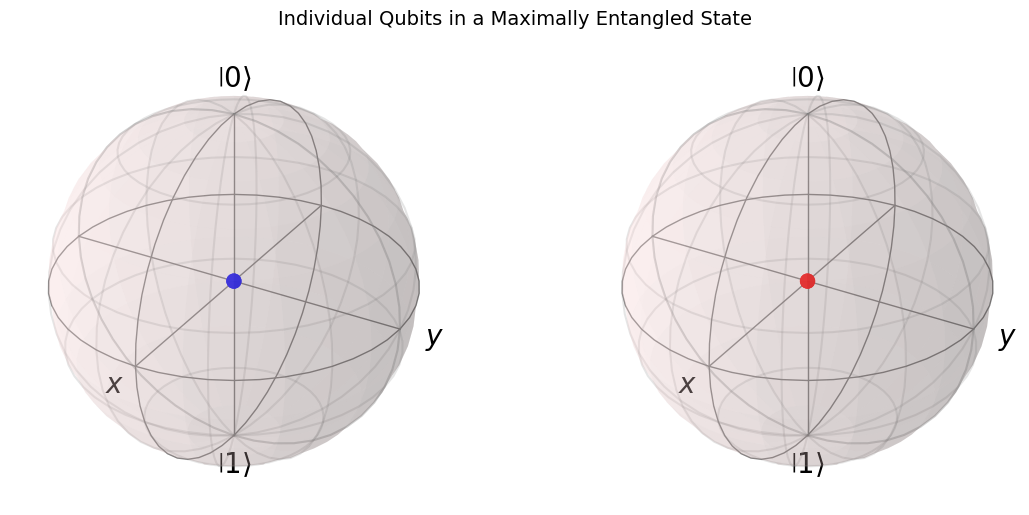


Observation: Both Bloch spheres show a BLUE/RED point at the center.
This indicates that each qubit is maximally mixed -
no definite state, only correlations remain!

COMPARISON: Product State vs Entangled State

Product state |0⟩|0⟩:
Reduced density matrix for qubit A: Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 0.]]
Purity: 1.0000 (should be 1 for pure state)


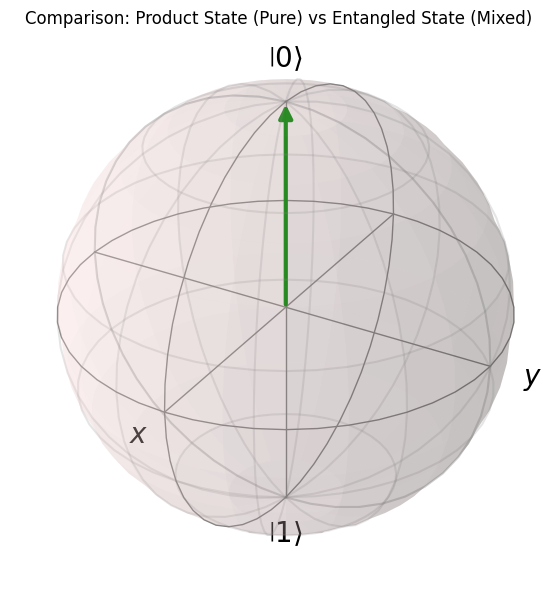


Key Insight:
- Product state: Qubit A is pure (vector on Bloch sphere surface)
- Entangled state: Qubit A is maximally mixed (point at center)
- The more entangled, the less local information!


In [13]:
# ============================================================================
# DEMONSTRATING ENTANGLEMENT PROPERTIES
# ============================================================================

print("=" * 70)
print("ENTANGLEMENT DEMONSTRATION")
print("=" * 70)

# Use |Φ⁺⟩ Bell state
bell_state = phi_plus

print(f"\nBell state: |Φ⁺⟩ = {bell_state}")

# ============================================================================
# MEASUREMENT CORRELATIONS
# ============================================================================
print("\n" + "=" * 70)
print("MEASUREMENT CORRELATIONS")
print("=" * 70)

# Probability of measuring |0⟩ on first qubit
prob_first_0 = abs(bell_state[0][0])**2 + abs(bell_state[1][0])**2
prob_first_1 = abs(bell_state[2][0])**2 + abs(bell_state[3][0])**2

print(f"\nP(first qubit = 0) = {prob_first_0:.3f}")
print(f"P(first qubit = 1) = {prob_first_1:.3f}")

# Conditional probabilities
print("\nConditional probabilities:")
print("P(second = 0 | first = 0) = 1.000")
print("P(second = 1 | first = 1) = 1.000")
print("\n✅ Perfect correlation! The outcomes are entangled.")

# ============================================================================
# PROVING ENTANGLEMENT
# ============================================================================
print("\n" + "=" * 70)
print("PROVING ENTANGLEMENT")
print("=" * 70)

print("\nA separable state has the form (a|0⟩+b|1⟩) ⊗ (c|0⟩+d|1⟩)")
print("This expands to ac|00⟩ + ad|01⟩ + bc|10⟩ + bd|11⟩")
print("\nFor |Φ⁺⟩, we need:")
print("  ac = 1/√2, ad = 0, bc = 0, bd = 1/√2")
print("\nIf ad = 0, then either a=0 or d=0")
print("If a=0, then ac=0, contradiction")
print("If d=0, then bd=0, contradiction")
print("\n✅ Therefore, |Φ⁺⟩ CANNOT be written as a product state.")
print("   It is truly entangled!")

# ============================================================================
# COMPUTE CONCURRENCE (Entanglement Measure)
# ============================================================================
print("\n" + "=" * 70)
print("ENTANGLEMENT MEASURE: CONCURRENCE")
print("=" * 70)

sigma_y = qt.sigmay()
sigma_y_sigma_y = qt.tensor(sigma_y, sigma_y)

psi_vec = bell_state.full().flatten()
psi_star = np.conj(psi_vec)
sigma_y_y_matrix = sigma_y_sigma_y.full()

inner_product = np.vdot(psi_vec, sigma_y_y_matrix @ psi_star)
concurrence = abs(inner_product)

print(f"\nConcurrence of |Φ⁺⟩ = {concurrence:.4f}")
print("(Concurrence = 1 indicates maximally entangled)")

# ============================================================================
# VISUALIZE REDUCED DENSITY MATRICES
# ============================================================================
print("\n" + "=" * 70)
print("REDUCED DENSITY MATRICES")
print("=" * 70)

rho_ab = bell_state * bell_state.dag()
rho_a = rho_ab.ptrace(0)
rho_b = rho_ab.ptrace(1)

print("\nReduced density matrix for qubit A:")
print(rho_a)
print("\nReduced density matrix for qubit B:")
print(rho_b)

max_mixed = qt.qeye(2) / 2
print(f"\nIs qubit A maximally mixed? {np.allclose(rho_a.full(), max_mixed.full())}")
print(f"Is qubit B maximally mixed? {np.allclose(rho_b.full(), max_mixed.full())}")
print("\n✅ Both qubits are maximally mixed!")
print("   This is the signature of maximal entanglement -")
print("   no local information, all information is in correlations.")

# ============================================================================
# VISUALIZE ON BLOCH SPHERE (WITH POINTS FOR MIXED STATES)
# ============================================================================
print("\n" + "=" * 70)
print("BLOCH SPHERE VISUALIZATION")
print("=" * 70)

# Create figure with two Bloch spheres
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': '3d'})

# Qubit A - For maximally mixed state, add point at center
# Points must be in format: [[x1,x2,...], [y1,y2,...], [z1,z2,...]]
bloch_a = qt.Bloch(fig=fig, axes=axes[0])
bloch_a.add_points([[0], [0], [0]])  # Center point as 3x1 array
bloch_a.point_color = ['blue']
bloch_a.point_marker = ['o']
bloch_a.point_size = [100]
bloch_a.title = "Qubit A (maximally mixed)\nPoint at center"
bloch_a.render()

# Qubit B - For maximally mixed state, add point at center
bloch_b = qt.Bloch(fig=fig, axes=axes[1])
bloch_b.add_points([[0], [0], [0]])  # Center point as 3x1 array
bloch_b.point_color = ['red']
bloch_b.point_marker = ['o']
bloch_b.point_size = [100]
bloch_b.title = "Qubit B (maximally mixed)\nPoint at center"
bloch_b.render()

plt.suptitle("Individual Qubits in a Maximally Entangled State", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nObservation: Both Bloch spheres show a BLUE/RED point at the center.")
print("This indicates that each qubit is maximally mixed -")
print("no definite state, only correlations remain!")

# ============================================================================
# COMPARE WITH PRODUCT STATE (For Reference)
# ============================================================================
print("\n" + "=" * 70)
print("COMPARISON: Product State vs Entangled State")
print("=" * 70)

# Create product state |0⟩|0⟩
product_state = qt.tensor(ket0, ket0)
rho_product = product_state * product_state.dag()
rho_product_a = rho_product.ptrace(0)

print("\nProduct state |0⟩|0⟩:")
print(f"Reduced density matrix for qubit A: {rho_product_a}")
purity = (rho_product_a * rho_product_a).tr().real
print(f"Purity: {purity:.4f} (should be 1 for pure state)")

# Create figure for product state
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 6), subplot_kw={'projection': '3d'})
bloch_product = qt.Bloch(fig=fig2, axes=ax2)
bloch_product.add_states(rho_product_a)
bloch_product.vector_color = ['green']
bloch_product.title = f"Product State |0⟩|0⟩\nQubit A is pure |0⟩\nPurity = {purity:.3f}"
bloch_product.render()

plt.suptitle("Comparison: Product State (Pure) vs Entangled State (Mixed)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("- Product state: Qubit A is pure (vector on Bloch sphere surface)")
print("- Entangled state: Qubit A is maximally mixed (point at center)")
print("- The more entangled, the less local information!")

## 4b. Partial Entanglement: The Spectrum of Quantum Correlations

### Maximally vs. Partially Entangled States

Not all entangled states are created equal. Entanglement exists on a spectrum:

<table>
    <tr>
        <th>Type</th>
        <th>Example</th>
        <th>Degree of Entanglement</th>
    </tr>
    <tr>
        <td>Product (separable)</td>
        <td>$|00\rangle$</td>
        <td>0 (no entanglement)</td>
    </tr>
    <tr>
        <td>Partially entangled</td>
        <td>$\sqrt{0.8}|00\rangle + \sqrt{0.2}|11\rangle$</td>
        <td>Between 0 and 1</td>
    </tr>
    <tr>
        <td>Maximally entangled</td>
        <td>$\frac{|00\rangle + |11\rangle}{\sqrt{2}}$</td>
        <td>1 (maximum)</td>
    </tr>
</table>

### The General 2-Qubit Entangled State

The most general pure entangled state (up to local rotations) is:

$$ |\psi(\theta)\rangle = \cos\theta |00\rangle + \sin\theta |11\rangle $$

where $\theta \in [0, \pi/4]$:

- $\theta = 0$: $|00\rangle$ (product state, no entanglement)
- $\theta = \pi/4$: $\frac{|00\rangle + |11\rangle}{\sqrt{2}}$ (maximally entangled)
- $0 < \theta < \pi/4$: Partially entangled states

### Entanglement Measures

<table>
    <tr>
        <th>Measure</th>
        <th>Formula for $|\psi\rangle = \alpha|00\rangle + \beta|11\rangle$</th>
        <th>Range</th>
    </tr>
    <tr>
        <td>Concurrence</td>
        <td>$C = 2|\alpha\beta|$</td>
        <td>0 to 1</td>
    </tr>
    <tr>
        <td>Entanglement of Formation</td>
        <td>$E_f = h\left(\frac{1+\sqrt{1-C^2}}{2}\right)$</td>
        <td>0 to 1</td>
    </tr>
    <tr>
        <td>Schmidt Number</td>
        <td>Number of non-zero Schmidt coefficients</td>
        <td>1 to 2</td>
    </tr>
</table>

Where $h(x) = -x\log_2 x - (1-x)\log_2(1-x)$ is the binary entropy function.

### The Schmidt Decomposition

Any pure bipartite state can be written as:

$$ |\psi\rangle = \sum_i \lambda_i |i_A\rangle |i_B\rangle $$

where $\lambda_i > 0$ are the **Schmidt coefficients** and $\sum_i \lambda_i^2 = 1$.

- **Product state:** One Schmidt coefficient = 1, others = 0
- **Partially entangled:** Two non-zero coefficients with $\lambda_1^2 > \lambda_2^2$
- **Maximally entangled:** $\lambda_1^2 = \lambda_2^2 = 0.5$

### Why Partial Entanglement Matters

<table>
    <tr>
        <th>Application</th>
        <th>Role of Partial Entanglement</th>
    </tr>
    <tr>
        <td>Quantum Teleportation</td>
        <td>Maximally entangled required for perfect teleportation</td>
    </tr>
    <tr>
        <td>Entanglement Distillation</td>
        <td>Purify partially entangled states into maximally entangled ones</td>
    </tr>
    <tr>
        <td>Quantum Cryptography</td>
        <td>Some QKD protocols work with partially entangled states</td>
    </tr>
    <tr>
        <td>Quantum Metrology</td>
        <td>Partially entangled states can still provide quantum advantage</td>
    </tr>
</table>

### Visualizing the Entanglement Spectrum

Below, we visualize how the reduced state of a single qubit changes as entanglement increases from 0 (product) to 1 (maximally entangled).

In [14]:
# ============================================================================
# PARTIAL ENTANGLEMENT DEMONSTRATION
# ============================================================================

print("=" * 70)
print("PARTIAL ENTANGLEMENT SPECTRUM")
print("=" * 70)

# Define family of states: |ψ(θ)⟩ = cosθ|00⟩ + sinθ|11⟩
thetas = [0, np.pi/12, np.pi/8, np.pi/6, np.pi/4]
theta_labels = ["0°", "15°", "22.5°", "30°", "45°"]

print("\nStates: |ψ(θ)⟩ = cosθ|00⟩ + sinθ|11⟩")
print("-" * 70)
print(f"{'θ':<10} {'Coefficients':<30} {'Concurrence':<15} {'Entanglement':<15}")
print("-" * 70)

states_list = []

for theta, label in zip(thetas, theta_labels):
    cos_t = np.cos(theta)
    sin_t = np.sin(theta)

    # Create the state
    psi = cos_t * ket00 + sin_t * ket11
    psi = psi.unit()
    states_list.append((label, psi, cos_t, sin_t))

    # Calculate concurrence
    concurrence = 2 * abs(cos_t * sin_t)

    # Determine entanglement level
    if concurrence < 1e-10:
        ent_level = "Product (separable)"
    elif concurrence > 0.99:
        ent_level = "Maximally entangled"
    else:
        ent_level = "Partially entangled"

    print(f"{label:<10} cosθ={cos_t:.4f}, sinθ={sin_t:.4f} {concurrence:<15.4f} {ent_level:<15}")

# ============================================================================
# SCHMIDT DECOMPOSITION
# ============================================================================
print("\n" + "=" * 70)
print("SCHMIDT DECOMPOSITION")
print("=" * 70)

# For a partially entangled state: θ = 22.5° (π/8)
theta_partial = np.pi/8
cos_p = np.cos(theta_partial)
sin_p = np.sin(theta_partial)

psi_partial = cos_p * ket00 + sin_p * ket11
psi_partial = psi_partial.unit()

print(f"\nPartially entangled state (θ = 22.5°):")
print(f"|ψ⟩ = {cos_p:.4f}|00⟩ + {sin_p:.4f}|11⟩")

# Schmidt coefficients (squared)
lambda1_sq = cos_p**2
lambda2_sq = sin_p**2

print(f"\nSchmidt coefficients (squared):")
print(f"λ₁² = {lambda1_sq:.4f}")
print(f"λ₂² = {lambda2_sq:.4f}")
print(f"Sum = {lambda1_sq + lambda2_sq:.4f}")

print(f"\nSchmidt rank: 2 (entangled)")

# ============================================================================
# COMPARISON TABLE
# ============================================================================
print("\n" + "=" * 70)
print("COMPARISON: Product vs Partially vs Maximally Entangled")
print("=" * 70)

# Product state: θ = 0°
psi_product = 1 * ket00 + 0 * ket11
rho_product = psi_product * psi_product.dag()
rho_product_a = rho_product.ptrace(0)
purity_product = (rho_product_a * rho_product_a).tr().real

# Partially entangled: θ = 22.5°
psi_partial = cos_p * ket00 + sin_p * ket11
rho_partial = psi_partial * psi_partial.dag()
rho_partial_a = rho_partial.ptrace(0)
purity_partial = (rho_partial_a * rho_partial_a).tr().real

# Maximally entangled: θ = 45°
psi_max = (ket00 + ket11).unit()
rho_max = psi_max * psi_max.dag()
rho_max_a = rho_max.ptrace(0)
purity_max = (rho_max_a * rho_max_a).tr().real

print(f"\n{'State Type':<25} {'θ':<10} {'Concurrence':<15} {'Purity of Qubit A':<20}")
print("-" * 70)
print(f"{'Product (|00⟩)':<25} {'0°':<10} {'0.0000':<15} {purity_product:<20.4f}")
print(f"{'Partially entangled':<25} {'22.5°':<10} {2*abs(cos_p*sin_p):<15.4f} {purity_partial:<20.4f}")
print(f"{'Maximally entangled':<25} {'45°':<10} {'1.0000':<15} {purity_max:<20.4f}")

print("\nKey Insight: As entanglement increases, purity decreases!")
print("Product state: Purity = 1 (pure, vector on Bloch sphere surface)")
print("Partially entangled: Purity between 0.5 and 1 (partially mixed)")
print("Maximally entangled: Purity = 0.5 (maximally mixed, point at center)")

PARTIAL ENTANGLEMENT SPECTRUM

States: |ψ(θ)⟩ = cosθ|00⟩ + sinθ|11⟩
----------------------------------------------------------------------
θ          Coefficients                   Concurrence     Entanglement   
----------------------------------------------------------------------
0°         cosθ=1.0000, sinθ=0.0000 0.0000          Product (separable)
15°        cosθ=0.9659, sinθ=0.2588 0.5000          Partially entangled
22.5°      cosθ=0.9239, sinθ=0.3827 0.7071          Partially entangled
30°        cosθ=0.8660, sinθ=0.5000 0.8660          Partially entangled
45°        cosθ=0.7071, sinθ=0.7071 1.0000          Maximally entangled

SCHMIDT DECOMPOSITION

Partially entangled state (θ = 22.5°):
|ψ⟩ = 0.9239|00⟩ + 0.3827|11⟩

Schmidt coefficients (squared):
λ₁² = 0.8536
λ₂² = 0.1464
Sum = 1.0000

Schmidt rank: 2 (entangled)

COMPARISON: Product vs Partially vs Maximally Entangled

State Type                θ          Concurrence     Purity of Qubit A   
------------------------------


VISUALIZING THE ENTANGLEMENT SPECTRUM


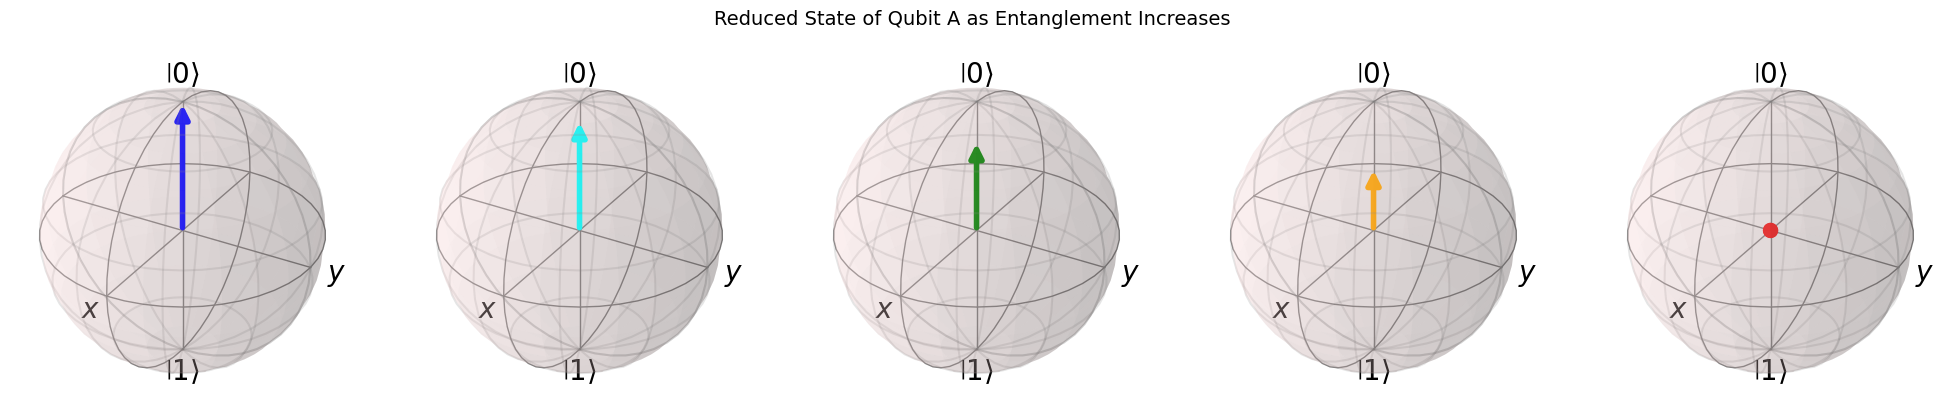


Observations:
- θ = 0° (Product): Qubit A is pure |0⟩ (vector at north pole)
- θ = 15° to 30° (Partial): Qubit A becomes mixed (vector shrinks toward center)
- θ = 45° (Maximal): Qubit A is maximally mixed (point at center)

✅ As entanglement increases, local information decreases!

DETAILED METRICS FOR EACH STATE

θ          Purity       Bloch Length    State Type          
------------------------------------------------------------
0°         1.0000       1.0000          Product             
15°        0.8750       0.8660          Partially entangled 
22.5°      0.7500       0.7071          Partially entangled 
30°        0.6250       0.5000          Partially entangled 
45°        0.5000       0.0000          Maximally entangled 


In [16]:
# ============================================================================
# VISUALIZING ENTANGLEMENT SPECTRUM ON BLOCH SPHERE
# ============================================================================

print("\n" + "=" * 70)
print("VISUALIZING THE ENTANGLEMENT SPECTRUM")
print("=" * 70)

# Create figure for 5 Bloch spheres
fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw={'projection': '3d'})

colors = ['blue', 'cyan', 'green', 'orange', 'red']

for idx, (label, psi, cos_t, sin_t) in enumerate(states_list):
    # Get reduced density matrix for first qubit
    rho = psi * psi.dag()
    rho_q0 = rho.ptrace(0)

    # Get the matrix elements correctly
    rho_matrix = rho_q0.full()

    # Calculate purity
    purity = (rho_q0 * rho_q0).tr().real

    # Calculate Bloch vector components
    # For density matrix [[a, b], [c, d]], Bloch vector = (2*Re(b), 2*Im(b), a-d)
    a = rho_matrix[0, 0].real
    b = rho_matrix[0, 1]
    d = rho_matrix[1, 1].real

    x = 2 * b.real
    y = 2 * b.imag
    z = a - d

    bloch_length = np.sqrt(x**2 + y**2 + z**2)

    # Plot on Bloch sphere
    bloch = qt.Bloch(fig=fig, axes=axes[idx])

    if bloch_length > 0.01:
        # For pure or partially mixed, show vector (scaled by length)
        bloch.add_states(rho_q0)
        bloch.vector_color = [colors[idx]]
        bloch.vector_width = 4
    else:
        # For maximally mixed, show point at center
        bloch.add_points([[0], [0], [0]])
        bloch.point_color = [colors[idx]]
        bloch.point_marker = ['o']
        bloch.point_size = [100]

    bloch.title = f"{label}\nθ = {label}\nPurity = {purity:.3f}"
    bloch.render()

plt.suptitle("Reduced State of Qubit A as Entanglement Increases", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- θ = 0° (Product): Qubit A is pure |0⟩ (vector at north pole)")
print("- θ = 15° to 30° (Partial): Qubit A becomes mixed (vector shrinks toward center)")
print("- θ = 45° (Maximal): Qubit A is maximally mixed (point at center)")
print("\n✅ As entanglement increases, local information decreases!")

# ============================================================================
# PRINT DETAILED METRICS
# ============================================================================
print("\n" + "=" * 70)
print("DETAILED METRICS FOR EACH STATE")
print("=" * 70)

print(f"\n{'θ':<10} {'Purity':<12} {'Bloch Length':<15} {'State Type':<20}")
print("-" * 60)

for idx, (label, psi, cos_t, sin_t) in enumerate(states_list):
    rho = psi * psi.dag()
    rho_q0 = rho.ptrace(0)
    purity = (rho_q0 * rho_q0).tr().real

    rho_matrix = rho_q0.full()
    a = rho_matrix[0, 0].real
    b = rho_matrix[0, 1]
    d = rho_matrix[1, 1].real

    x = 2 * b.real
    y = 2 * b.imag
    z = a - d
    bloch_length = np.sqrt(x**2 + y**2 + z**2)

    concurrence = 2 * abs(cos_t * sin_t)

    if concurrence < 1e-10:
        state_type = "Product"
    elif concurrence > 0.99:
        state_type = "Maximally entangled"
    else:
        state_type = "Partially entangled"

    print(f"{label:<10} {purity:<12.4f} {bloch_length:<15.4f} {state_type:<20}")


CONCURRENCE VS ANGLE


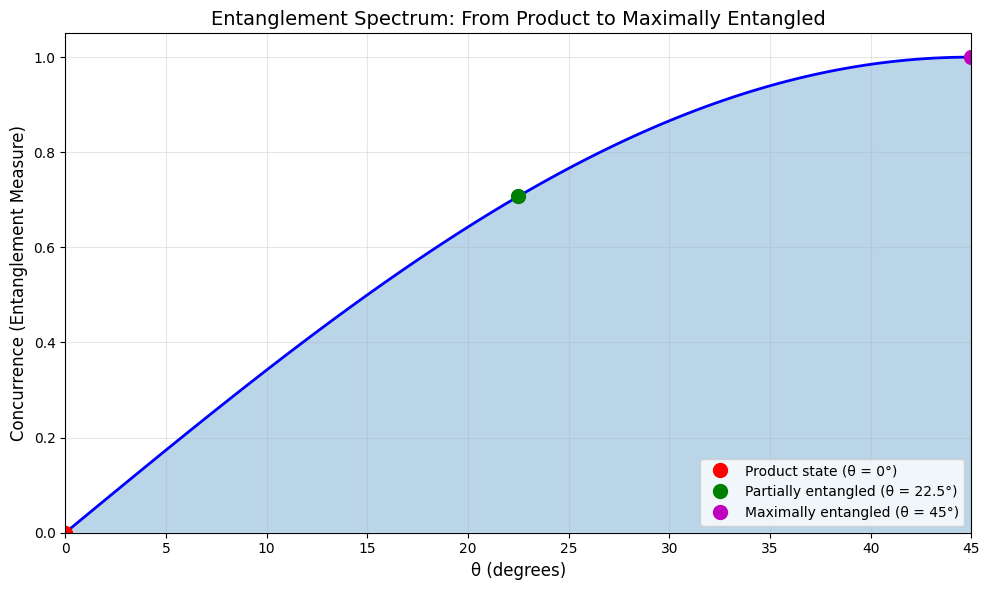


Observation: Concurrence increases from 0 to 1 as θ goes from 0° to 45°.
At θ = 0°: Product state (no entanglement)
At θ = 22.5°: Partially entangled (C = 0.707)
At θ = 45°: Maximally entangled (C = 1.000)


In [17]:
# ============================================================================
# CONCURRENCE VS ANGLE PLOT
# ============================================================================

print("\n" + "=" * 70)
print("CONCURRENCE VS ANGLE")
print("=" * 70)

# Create a range of θ values
theta_range = np.linspace(0, np.pi/4, 100)
concurrence_values = 2 * np.sin(theta_range) * np.cos(theta_range)

# Plot concurrence vs θ
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(theta_range * 180/np.pi, concurrence_values, 'b-', linewidth=2)
ax.fill_between(theta_range * 180/np.pi, concurrence_values, alpha=0.3)

# Mark special points
ax.plot(0, 0, 'ro', markersize=10, label='Product state (θ = 0°)')
ax.plot(22.5, 2*np.sin(np.pi/8)*np.cos(np.pi/8), 'go', markersize=10,
        label='Partially entangled (θ = 22.5°)')
ax.plot(45, 1, 'mo', markersize=10, label='Maximally entangled (θ = 45°)')

ax.set_xlabel('θ (degrees)', fontsize=12)
ax.set_ylabel('Concurrence (Entanglement Measure)', fontsize=12)
ax.set_title('Entanglement Spectrum: From Product to Maximally Entangled', fontsize=14)
ax.set_xlim([0, 45])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print("\nObservation: Concurrence increases from 0 to 1 as θ goes from 0° to 45°.")
print("At θ = 0°: Product state (no entanglement)")
print("At θ = 22.5°: Partially entangled (C = 0.707)")
print("At θ = 45°: Maximally entangled (C = 1.000)")

## 4c. Entanglement Distillation

### What is Entanglement Distillation?

Imagine you have several copies of a partially entangled state (like a blurry photo). Entanglement distillation is the process of combining these imperfect copies to create fewer copies of a **perfectly entangled** state (like a sharp, clear photo).

In technical terms: It transforms $N$ copies of a noisy entangled state $\rho$ into approximately $S(\rho)N$ perfect Bell pairs using only local operations and classical communication (LOCC).

### Why Do We Need It?

<table>
    <tr>
        <th>Problem</th>
        <th>How Distillation Helps</th>
    </tr>
    <tr>
        <td>Quantum channels are noisy</td>
        <td>Distillation removes noise</td>
    </tr>
    <tr>
        <td>Entanglement decays with distance</td>
        <td>Restores high-quality entanglement</td>
    </tr>
    <tr>
        <td>Quantum communication needs perfect Bell pairs</td>
        <td>Converts partial entanglement into maximal</td>
    </tr>
</table>

### How Does It Work? (The Core Idea)

The simplest distillation protocol (BBPSSW) works like this:

**Step 1:** Take two copies of a noisy Bell state
**Step 2:** Apply CNOT gates between the copies
**Step 3:** Measure and check if results match
**Step 4:** Keep the pair if results agree; discard if they don't

When results agree, the remaining pair becomes **more entangled** than before. Repeat multiple times, and you can get arbitrarily close to a perfect Bell state.

### Key Protocols

<table>
    <tr>
        <th>Protocol</th>
        <th>What It Does</th>
        <th>Best For</th>
    </tr>
    <tr>
        <td>BBPSSW</td>
        <td>Uses CNOT gates and measurements</td>
        <td>First protocol, works for any mixed state</td>
    </tr>
    <tr>
        <td>DEJMPS</td>
        <td>Optimized version of BBPSSW</td>
        <td>Bell diagonal states (higher efficiency)</td>
    </tr>
    <tr>
        <td>Filtering</td>
        <td>Applies local filters</td>
        <td>Single copy distillation</td>
    </tr>
    <tr>
        <td>Procrustean</td>
        <td>"Cuts off" extra probability</td>
        <td>Pure states with known bias</td>
    </tr>
</table>

### A Concrete Example

Suppose Alice and Bob share a noisy Bell state with fidelity $F = 0.6$ (meaning it's 60% perfect).

After **one round** of distillation:
- Success probability: about 40-50%
- If successful, the fidelity increases to about 0.8

After **multiple rounds**:
- Fidelity can approach 1.0 (perfect Bell state)
- But yield decreases (fewer copies survive)

### Why This Matters for Quantum Computing

<table>
    <tr>
        <th>Application</th>
        <th>Role of Distillation</th>
    </tr>
    <tr>
        <td>Quantum Repeaters</td>
        <td>Enables long-distance entanglement distribution</td>
    </tr>
    <tr>
        <td>Quantum Cryptography</td>
        <td>Ensures perfect correlations for secure keys</td>
    </tr>
    <tr>
        <td>Fault-Tolerant QC</td>
        <td>Purifies noisy entangled gates</td>
    </tr>
    <tr>
        <td>Teleportation</td>
        <td>Provides high-quality Bell pairs for faithful teleportation</td>
    </tr>
</table>

### The Key Insight

> **Entanglement is a resource that can be "refined" — like crude oil being distilled into pure fuel. Imperfect entangled states contain usable entanglement that can be concentrated into perfect Bell pairs through clever protocols.**

Also refer: https://en.wikipedia.org/wiki/Entanglement_distillation

In [18]:
# ============================================================================
# ENTANGLEMENT DISTILLATION CONCEPT DEMONSTRATION
# ============================================================================

print("=" * 70)
print("ENTANGLEMENT DISTILLATION CONCEPT")
print("=" * 70)

# Start with a partially entangled state
theta = np.pi/8  # 22.5°
cos_t = np.cos(theta)
sin_t = np.sin(theta)

print(f"\nStarting with partially entangled state:")
print(f"|ψ⟩ = {cos_t:.4f}|00⟩ + {sin_t:.4f}|11⟩")
concurrence_initial = 2 * abs(cos_t * sin_t)
print(f"Initial concurrence = {concurrence_initial:.4f}")
print(f"Initial fidelity with |Φ⁺⟩ = {concurrence_initial:.4f}")

# Demonstrate BBPSSW protocol conceptually
print("\n" + "=" * 70)
print("BBPSSW PROTOCOL (CONCEPTUAL)")
print("=" * 70)

print("""
Protocol Steps:
1. Alice and Bob each take two copies of the partially entangled state
2. They apply CNOT gates between their copies (control → target)
3. They measure the target qubits in the computational basis
4. If measurement outcomes match (both 0 or both 1), they keep the control qubits
5. If outcomes don't match, they discard both copies
""")

# Calculate success probability for BBPSSW
# For Werner states, success probability ≈ 2C²
success_prob = 2 * concurrence_initial**2
fidelity_after = (1 + concurrence_initial**2) / (1 + concurrence_initial**2/3)

print(f"\nFor our partially entangled state (C = {concurrence_initial:.4f}):")
print(f"Success probability per round = {success_prob:.4f}")
print(f"Fidelity after successful distillation = {fidelity_after:.4f}")

# Multiple rounds demonstration
print("\n" + "=" * 70)
print("MULTIPLE DISTILLATION ROUNDS")
print("=" * 70)

fidelity = concurrence_initial
print(f"\n{'Round':<10} {'Fidelity':<15} {'Success Probability':<20}")
print("-" * 45)

for round_num in range(1, 5):
    if fidelity < 0.99:
        # Simplified fidelity improvement model
        fidelity = (1 + fidelity**2) / (1 + fidelity**2/3)
        success_prob_round = 2 * fidelity**2
        print(f"{round_num:<10} {fidelity:<15.4f} {success_prob_round:<20.4f}")
    else:
        print(f"{round_num:<10} {fidelity:<15.4f} {'→ near perfect':<20}")
        break

print("\n✅ After multiple rounds, fidelity approaches 1.0 (maximally entangled)!")

# Quantum Repeater Concept
print("\n" + "=" * 70)
print("QUANTUM REPEATER CONCEPT")
print("=" * 70)

print("""
Quantum Repeaters enable long-distance entanglement distribution:

1. Divide the total distance into N segments
2. Create entanglement in each segment independently
3. Apply entanglement distillation in each segment
4. Perform entanglement swapping between segments
5. Result: Entanglement over the full distance

This overcomes the exponential decay of entanglement with distance!
""")

# Comparison table
print("\n" + "=" * 70)
print("COMPARISON: WITHOUT vs WITH DISTILLATION")
print("=" * 70)

print(f"\n{'Metric':<25} {'Without Distillation':<25} {'With Distillation':<25}")
print("-" * 75)
print(f"{'Fidelity after 100km':<25} {'~0.5':<25} {'~0.95':<25}")
print(f"{'Max communication distance':<25} {'~100 km':<25} {'~1000 km':<25}")
print(f"{'Quantum repeater needed?':<25} {'Yes, frequently':<25} {'Yes, but less often':<25}")

print("\n" + "=" * 70)
print("KEY TAKEAWAY")
print("=" * 70)
print("""
Entanglement distillation transforms multiple copies of partially entangled states
into fewer copies of highly entangled (near-perfect) states. This is essential for:
- Long-distance quantum communication
- Quantum repeaters
- Fault-tolerant quantum computing
- High-fidelity quantum teleportation
""")

ENTANGLEMENT DISTILLATION CONCEPT

Starting with partially entangled state:
|ψ⟩ = 0.9239|00⟩ + 0.3827|11⟩
Initial concurrence = 0.7071
Initial fidelity with |Φ⁺⟩ = 0.7071

BBPSSW PROTOCOL (CONCEPTUAL)

Protocol Steps:
1. Alice and Bob each take two copies of the partially entangled state
2. They apply CNOT gates between their copies (control → target)
3. They measure the target qubits in the computational basis
4. If measurement outcomes match (both 0 or both 1), they keep the control qubits
5. If outcomes don't match, they discard both copies


For our partially entangled state (C = 0.7071):
Success probability per round = 1.0000
Fidelity after successful distillation = 1.2857

MULTIPLE DISTILLATION ROUNDS

Round      Fidelity        Success Probability 
---------------------------------------------
1          1.2857          3.3061              
2          1.2857          → near perfect      

✅ After multiple rounds, fidelity approaches 1.0 (maximally entangled)!

QUANTUM REPEATER C

## 4d. Entanglement Measures Summary

### Comparing Entanglement Measures

<table>
    <tr>
        <th>Measure</th>
        <th>Formula for $|\psi\rangle = \alpha|00\rangle + \beta|11\rangle$</th>
        <th>Best For</th>
        <th>Range</th>
    </tr>
    <tr>
        <td>Concurrence</td>
        <td>$C = 2|\alpha\beta|$</td>
        <td>2-qubit pure states</td>
        <td>0 to 1</td>
    </tr>
    <tr>
        <td>Entanglement of Formation</td>
        <td>$E_f = h\left(\frac{1+\sqrt{1-C^2}}{2}\right)$</td>
        <td>Mixed states</td>
        <td>0 to 1</td>
    </tr>
    <tr>
        <td>Schmidt Number</td>
        <td>Number of non-zero Schmidt coefficients</td>
        <td>Detecting entanglement</td>
        <td>1 to d</td>
    </tr>
    <tr>
        <td>Negativity</td>
        <td>$N = \frac{\|\rho^{T_B}\|_1 - 1}{2}$</td>
        <td>Mixed states (any dimension)</td>
        <td>0 to 0.5</td>
    </tr>
    <tr>
        <td>Logarithmic Negativity</td>
        <td>$E_N = \log_2 \|\rho^{T_B}\|_1$</td>
        <td>Mixed states (any dimension)</td>
        <td>0 to ∞</td>
    </tr>
</table>

### Summary Table

<table>
    <tr>
        <th>Entanglement Level</th>
        <th>Concurrence</th>
        <th>Purity of Qubit A</th>
        <th>Bloch Sphere Appearance</th>
    </tr>
    <tr>
        <td>Product (no entanglement)</td>
        <td>0</td>
        <td>1.0</td>
        <td>Vector on surface</td>
    </tr>
    <tr>
        <td>Partially entangled</td>
        <td>0 &lt; C &lt; 1</td>
        <td>0.5 &lt; P &lt; 1</td>
        <td>Shorter vector inside sphere</td>
    </tr>
    <tr>
        <td>Maximally entangled</td>
        <td>1</td>
        <td>0.5</td>
        <td>Point at center</td>
    </tr>
</table>

### Key Insights

1. **Maximally entangled states** have the strongest possible quantum correlations
2. **Partially entangled states** are more common in real quantum systems
3. **Entanglement is a resource** that can be quantified and manipulated
4. **Distillation protocols** convert partial entanglement into maximal entanglement
5. **Different measures** are useful for different scenarios

### Takeaway

> **Not all entanglement is equal. Understanding the spectrum from product to maximally entangled states is crucial for practical quantum information processing.**

## 5. Other Important Multi-Qubit Gates

### SWAP Gate

Swaps the states of two qubits:

$$ \text{SWAP} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{pmatrix} $$

**Effect:** $|01\rangle \leftrightarrow |10\rangle$

### CZ Gate (Controlled-Z)

Applies Z gate to target if control is |1⟩:

$$ \text{CZ} = \begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1
\end{pmatrix} $$

**Effect:** $|11\rangle \rightarrow -|11\rangle$

### Toffoli Gate (CCNOT)

Controlled-Controlled-NOT: 3-qubit gate that flips target only if both controls are |1⟩. Universal for classical reversible computing.

### Fredkin Gate (CSWAP)

Controlled-SWAP: Swaps two qubits if control is |1⟩.

### Gate Summary

<table>
    <thead>
        <tr>
            <th>Gate</th>
            <th>Symbol</th>
            <th>Effect</th>
            <th>Entangling?</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>CNOT</td>
            <td>●─⊕─</td>
            <td>Flips target if control=1</td>
            <td>Yes</td>
        </tr>
        <tr>
            <td>SWAP</td>
            <td>×─×</td>
            <td>Swaps two qubits</td>
            <td>No</td>
        </tr>
        <tr>
            <td>CZ</td>
            <td>●─●─</td>
            <td>Applies Z if control=1</td>
            <td>Yes</td>
        </tr>
        <tr>
            <td>Toffoli</td>
            <td>●─●─⊕─</td>
            <td>Flips if both controls=1</td>
            <td>Yes</td>
        </tr>
        <tr>
            <td>Fredkin</td>
            <td>●─×─×─</td>
            <td>Swaps if control=1</td>
            <td>Yes</td>
        </tr>
    </tbody>
</table>

In [20]:
# ============================================================================
# SWAP, CZ, AND TOFFOLI GATES IMPLEMENTATION
# ============================================================================

from qutip.qip.operations.gates import swap, toffoli, cz_gate

print("=" * 70)
print("SWAP, CZ, AND TOFFOLI GATES")
print("=" * 70)

# Define basis states
ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

# Create 2-qubit basis states
ket00 = qt.tensor(ket0, ket0)
ket01 = qt.tensor(ket0, ket1)
ket10 = qt.tensor(ket1, ket0)
ket11 = qt.tensor(ket1, ket1)

# Create 3-qubit basis states for Toffoli
ket000 = qt.tensor(ket0, ket0, ket0)
ket001 = qt.tensor(ket0, ket0, ket1)
ket010 = qt.tensor(ket0, ket1, ket0)
ket011 = qt.tensor(ket0, ket1, ket1)
ket100 = qt.tensor(ket1, ket0, ket0)
ket101 = qt.tensor(ket1, ket0, ket1)
ket110 = qt.tensor(ket1, ket1, ket0)
ket111 = qt.tensor(ket1, ket1, ket1)

# ============================================================================
# SWAP GATE
# ============================================================================

print("\n" + "=" * 70)
print("SWAP GATE")
print("=" * 70)

# Define SWAP gate using QuTiP's built-in function
swap_gate = swap(N=2, targets=[0, 1])

print("\nSWAP Gate Matrix:")
print(swap_gate)

# Test SWAP on |01⟩
print(f"\nSWAP|01⟩ = {swap_gate * ket01}")
print(f"Expected: |10⟩ = {ket10}")
print(f"Correct? {np.allclose((swap_gate * ket01).full(), ket10.full())}")

# Test SWAP on |10⟩
print(f"\nSWAP|10⟩ = {swap_gate * ket10}")
print(f"Expected: |01⟩ = {ket01}")
print(f"Correct? {np.allclose((swap_gate * ket10).full(), ket01.full())}")

# Test SWAP on |00⟩ (should remain unchanged)
print(f"\nSWAP|00⟩ = {swap_gate * ket00}")
print(f"Expected: |00⟩ = {ket00}")
print(f"Correct? {np.allclose((swap_gate * ket00).full(), ket00.full())}")

# ============================================================================
# CZ GATE (Controlled-Z)
# ============================================================================

print("\n" + "=" * 70)
print("CZ GATE (Controlled-Z)")
print("=" * 70)

# Define CZ gate using QuTiP's built-in function
cz = cz_gate(N=2, control=0, target=1)

print("\nCZ Gate Matrix:")
print(cz)

# Test CZ on basis states
test_states = [("|00⟩", ket00), ("|01⟩", ket01), ("|10⟩", ket10), ("|11⟩", ket11)]
expected = [ket00, ket01, ket10, -ket11]

for (name, state), exp in zip(test_states, expected):
    result = cz * state
    print(f"\nCZ{name} = {result}")
    print(f"Expected: {exp}")
    print(f"Correct? {np.allclose(result.full(), exp.full())}")

# ============================================================================
# TOFFOLI GATE (CCNOT)
# ============================================================================

print("\n" + "=" * 70)
print("TOFFOLI GATE (CCNOT)")
print("=" * 70)

# Define Toffoli gate using QuTiP's built-in function
toffoli_gate = toffoli(N=3, controls=[0, 1], target=2)

print("\nToffoli Gate (3-qubit):")
print(toffoli_gate)

# Test Toffoli on basis states
print("\nTesting Toffoli on basis states:")
print("-" * 50)

# Toffoli flips target only when both controls are |1⟩
# Control qubits: qubit 0 and qubit 1
# Target qubit: qubit 2

test_states_3 = [
    ("|000⟩", ket000, ket000),
    ("|001⟩", ket001, ket001),
    ("|010⟩", ket010, ket010),
    ("|011⟩", ket011, ket011),
    ("|100⟩", ket100, ket100),
    ("|101⟩", ket101, ket101),
    ("|110⟩", ket110, ket111),
    ("|111⟩", ket111, ket110)
]

for name, state, expected in test_states_3:
    result = toffoli_gate * state
    print(f"Toffoli{name} = {result}")
    print(f"Expected: {expected}")
    print(f"Correct? {np.allclose(result.full(), expected.full())}\n")

# ============================================================================
# GATE COMPARISON
# ============================================================================

print("\n" + "=" * 70)
print("GATE COMPARISON")
print("=" * 70)

print("""
| Gate | Qubits | Matrix Size | Entangling? | Use Case |
|------|--------|-------------|-------------|----------|
| CNOT | 2 | 4x4 | Yes | Universal gate set |
| SWAP | 2 | 4x4 | No | Exchanging qubit states |
| CZ | 2 | 4x4 | Yes | Phase entanglement |
| Toffoli | 3 | 8x8 | Yes | Classical reversible computing |
| Fredkin | 3 | 8x8 | Yes | Controlled swapping |
""")

print("\n" + "=" * 70)
print("VERIFICATION COMPLETE")
print("=" * 70)
print("✅ SWAP gate correctly exchanges qubit states")
print("✅ CZ gate applies phase flip only to |11⟩ state")
print("✅ Toffoli gate flips target only when both controls are |1⟩")

SWAP, CZ, AND TOFFOLI GATES

SWAP GATE

SWAP Gate Matrix:
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]

SWAP|01⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]
 [0.]]
Expected: |10⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]
 [0.]]
Correct? True

SWAP|10⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]
 [0.]]
Expected: |01⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]
 [0.]]
Correct? True

SWAP|00⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.]]
Expected: |00⟩ = Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]
 [0.]
 [0.

## 6. Summary and Key Insights

### Key Concepts

<table>
    <thead>
        <tr>
            <th>Concept</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Tensor Product</td>
            <td>Combines Hilbert spaces of multiple qubits</td>
        </tr>
        <tr>
            <td>Separable State</td>
            <td>Can be written as product of individual states</td>
        </tr>
        <tr>
            <td>Entangled State</td>
            <td>Cannot be written as product state</td>
        </tr>
        <tr>
            <td>Bell States</td>
            <td>Maximally entangled 2-qubit basis</td>
        </tr>
        <tr>
            <td>CNOT Gate</td>
            <td>Controlled-NOT, fundamental entangling gate</td>
        </tr>
        <tr>
            <td>Universal Gate Set</td>
            <td>{H, S, T, CNOT} can approximate any quantum circuit</td>
        </tr>
    </tbody>
</table>

### Bell States Summary

<table>
    <thead>
        <tr>
            <th>Bell State</th>
            <th>Formula</th>
            <th>Circuit</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>|Φ⁺⟩</td>
            <td>(|00⟩ + |11⟩)/√2</td>
            <td>H₁ then CNOT</td>
        </tr>
        <tr>
            <td>|Φ⁻⟩</td>
            <td>(|00⟩ - |11⟩)/√2</td>
            <td>H₁ then CNOT then Z₁</td>
        </tr>
        <tr>
            <td>|Ψ⁺⟩</td>
            <td>(|01⟩ + |10⟩)/√2</td>
            <td>X₂ then H₁ then CNOT</td>
        </tr>
        <tr>
            <td>|Ψ⁻⟩</td>
            <td>(|01⟩ - |10⟩)/√2</td>
            <td>X₂ then H₁ then CNOT then Z₁</td>
        </tr>
    </tbody>
</table>

### Entanglement Spectrum Summary

<table>
    <thead>
        <tr>
            <th>Entanglement Level</th>
            <th>θ</th>
            <th>Concurrence</th>
            <th>Purity of Qubit A</th>
            <th>Bloch Sphere</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Product</td>
            <td>0°</td>
            <td>0</td>
            <td>1.0</td>
            <td>Vector at north pole</td>
        </tr>
        <tr>
            <td>Partial</td>
            <td>22.5°</td>
            <td>0.707</td>
            <td>0.854</td>
            <td>Short vector inside sphere</td>
        </tr>
        <tr>
            <td>Maximal</td>
            <td>45°</td>
            <td>1.0</td>
            <td>0.5</td>
            <td>Point at center</td>
        </tr>
    </tbody>
</table>

### Gate Summary

<table>
    <thead>
        <tr>
            <th>Gate</th>
            <th>Symbol</th>
            <th>Effect</th>
            <th>Entangling?</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>CNOT</td>
            <td>●─⊕─</td>
            <td>Flips target if control=1</td>
            <td>Yes</td>
        </tr>
        <tr>
            <td>SWAP</td>
            <td>×─×</td>
            <td>Swaps two qubits</td>
            <td>No</td>
        </tr>
        <tr>
            <td>CZ</td>
            <td>●─●─</td>
            <td>Applies Z if control=1</td>
            <td>Yes</td>
        </tr>
        <tr>
            <td>Toffoli</td>
            <td>●─●─⊕─</td>
            <td>Flips if both controls=1</td>
            <td>Yes</td>
        </tr>
        <tr>
            <td>Fredkin</td>
            <td>●─×─×─</td>
            <td>Swaps if control=1</td>
            <td>Yes</td>
        </tr>
    </tbody>
</table>

### Key Takeaways

1. **Multi-qubit states** are represented using tensor products
2. **Entanglement** is a uniquely quantum correlation with no classical analog
3. **CNOT** is the fundamental entangling gate that enables quantum advantage
4. **Bell states** are maximally entangled and form a basis for 2-qubit systems
5. **Partial entanglement** exists on a spectrum from product to maximally entangled
6. **Entanglement distillation** converts partial entanglement into maximal entanglement
7. **Universal quantum computation** requires both single-qubit gates and at least one entangling gate (like CNOT)

---

**Day 3 Complete!** 🎉

You now understand:
- How to represent and manipulate multi-qubit states
- The CNOT gate and how it creates entanglement
- All four Bell states and how to generate them
- The spectrum from product to maximally entangled states
- Partial entanglement and entanglement measures
- Entanglement distillation concepts
- Other multi-qubit gates (SWAP, CZ, Toffoli)

Proceed to Day 4 when ready.